# HOUSE PRICE PREDICTION PROJECT

# 1. Project Introduction

 House Price Prediction is a Machine Learning project that aims to predict the price of a house based on various features such as area, number of bedrooms, bathrooms, location, and other property-related factors.

 In this project, we will perform data cleaning, exploratory data analysis (EDA), feature engineering, and visualization. After preparing the data, we will train a Machine Learning model to predict house price and evaluate its performance using suitable evaluation metrics.

 Objective:

 -- Understand the factors affecting house prices.

 -- Clean and prepare the dataset.

 -- Perform EDA and visualize important patterns.

 -- Build a Machine Learning model for price prediction.

 -- Evaluate the model's performance.

 -- Identify the most important features affecting house prices.

# 2. Importing Required Libraries

In [1]:
# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Numpy for numerical calculations
import numpy as np

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Display all columns of the dataset
pd.set_option("display.max_columns", None)

# Print confirmation message
print("All libraries imported successfully!")

All libraries imported successfully!


# 3. Load the Dataset

In [2]:
# Load the house price dataset
df = pd.read_csv("house_data.csv")

# Display the dataset
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


# DATA UNDERSTANDING

# 4. Checking Dataset Shape

In [3]:
# Check the number of rows and columns in the dataset
df.shape

(21613, 21)

# 5. Checking Column Names

In [4]:
# Display all column names in the dataset
df.columns.tolist()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

# 6. Checking Dataset Information

In [5]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# 7. Checking Statistical Summary of the Dataset

In [6]:
# Display statistical summary of numerial columns
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# 8. Checking Missing Values

In [7]:
# Checking the number of missing values in each column
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# 9. Checking Duplicate Values

In [8]:
# check the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

# 10. Checking Data Types

In [9]:
# Display the data type of each column
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

# 11. Displaying First 10 Rows

In [10]:
# Display the first 10 rows of the dataset
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


# 12. Displaying Last 10 Rows

In [11]:
# Display the last 10 rows of the dataset
df.tail(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21603,7852140040,20140825T000000,507250.0,3,2.50,2270,5536,2.0,0,0,3,8,2270,0,2003,0,98065,47.5389,-121.881,2270,5731
21604,9834201367,20150126T000000,429000.0,3,2.00,1490,1126,3.0,0,0,3,8,1490,0,2014,0,98144,47.5699,-122.288,1400,1230
21605,3448900210,20141014T000000,610685.0,4,2.50,2520,6023,2.0,0,0,3,9,2520,0,2014,0,98056,47.5137,-122.167,2520,6023
21606,7936000429,20150326T000000,1007500.0,4,3.50,3510,7200,2.0,0,0,3,9,2600,910,2009,0,98136,47.5537,-122.398,2050,6200
21607,2997800021,20150219T000000,475000.0,3,2.50,1310,1294,2.0,0,0,3,8,1180,130,2008,0,98116,47.5773,-122.409,1330,1265
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,3,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


# 13. Checking Unique Values

In [12]:
# Display the number of unique values in each column
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

# DATA CLEANING

# 14. Handling Missing Values

In [13]:
# Fill missing values in numerical columns with theeir median
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Check missing values after handling them
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# 15. Checking Duplicate Values

In [14]:
# Check the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

# 16. Removing Duplicate Values

In [15]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Check the dataset shape after removing duplicates
df.shape

(21613, 21)

# 17. Checking Data Types

In [16]:
# Display the data types of all columns
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

# 18. Converting Data Types

In [17]:
# Convert suitable columns to numeric data types
df = df.apply(pd.to_numeric, errors="ignore")

# display the updated data types 
df.dtypes

C:\Users\Asus\AppData\Local\Temp\ipykernel_13828\1310841454.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

# 19. Checking Outliers

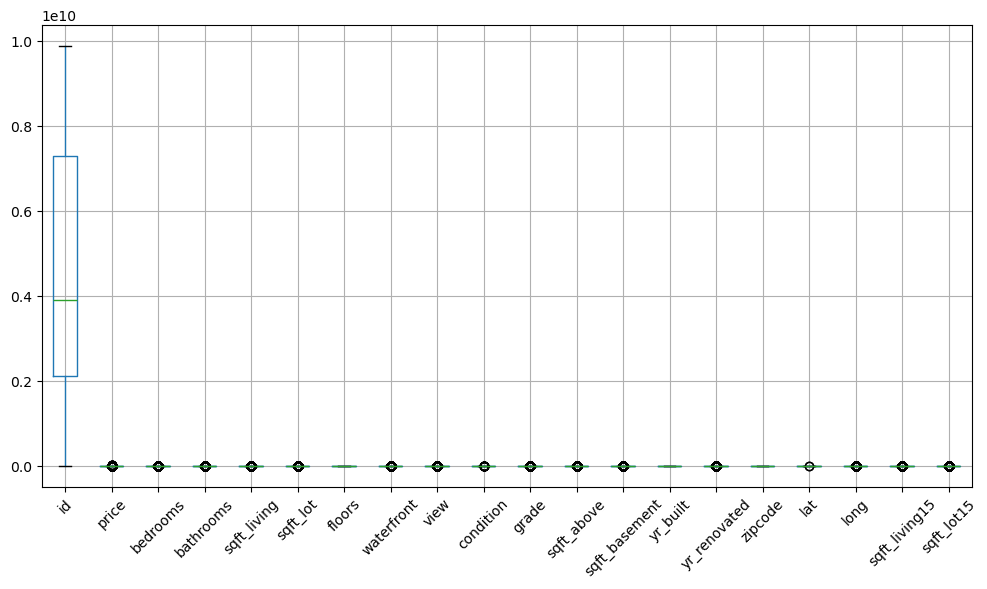

In [18]:
# Check for outlier in numerical columns using boxplots
df.select_dtypes(include=np.number).boxplot(figsize=(12,6))

# rotating the plot
plt.xticks(rotation=45)

# Display the plot
plt.show()

# 20. Handling Outliers

In [19]:
# Remove extreme outliers using the IQR method
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR


    df = df[(df[column]>=lower_bound) & (df[column]<=upper_bound)]

# Display the updated dataset shape 
df.shape

(13868, 21)

# 21. Final Data Check

In [20]:
# Perform a final check after data cleaning
print("Dataset Shape:", df.shape)

# Check remaining missing values
print("\n Missing Values:")
print(df.isnull().sum())

# Check remaining duplicate rows
print("\n Duplicate Rows:",
df.duplicated().sum())

Dataset Shape: (13868, 21)

 Missing Values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

 Duplicate Rows: 0


# EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION

# 22. Distribution of House Prices

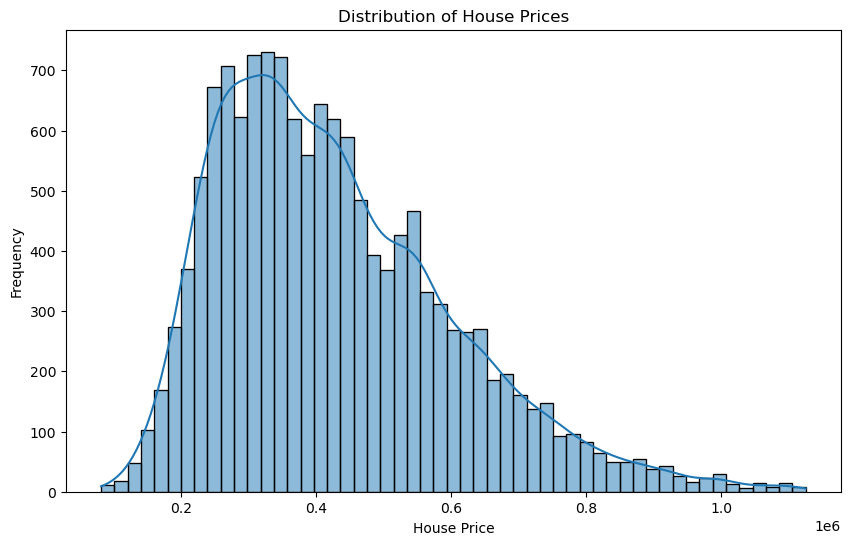

In [21]:
# Plot the distribution of house prices
plt.figure(figsize=(10,6))
sns.histplot(df["price"], kde=True)

# Add title and labels
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

# Display the plot
plt.show()

# 23. House Price Boxplot

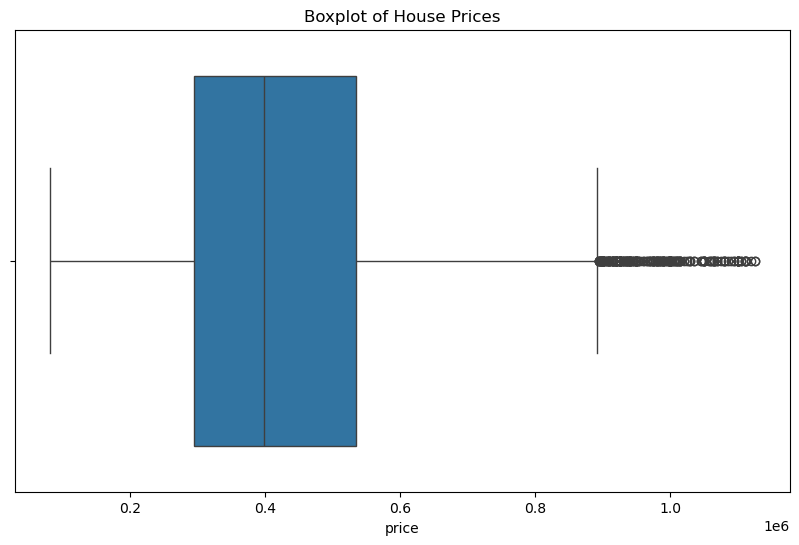

In [22]:
# Create a boxplot to identify the distribution and possible outliers
plt.figure(figsize=(10,6))
sns.boxplot(x=df["price"])

# Add title
plt.title("Boxplot of House Prices")

# Display the plot
plt.show()

# 24. Correlation Heatmap

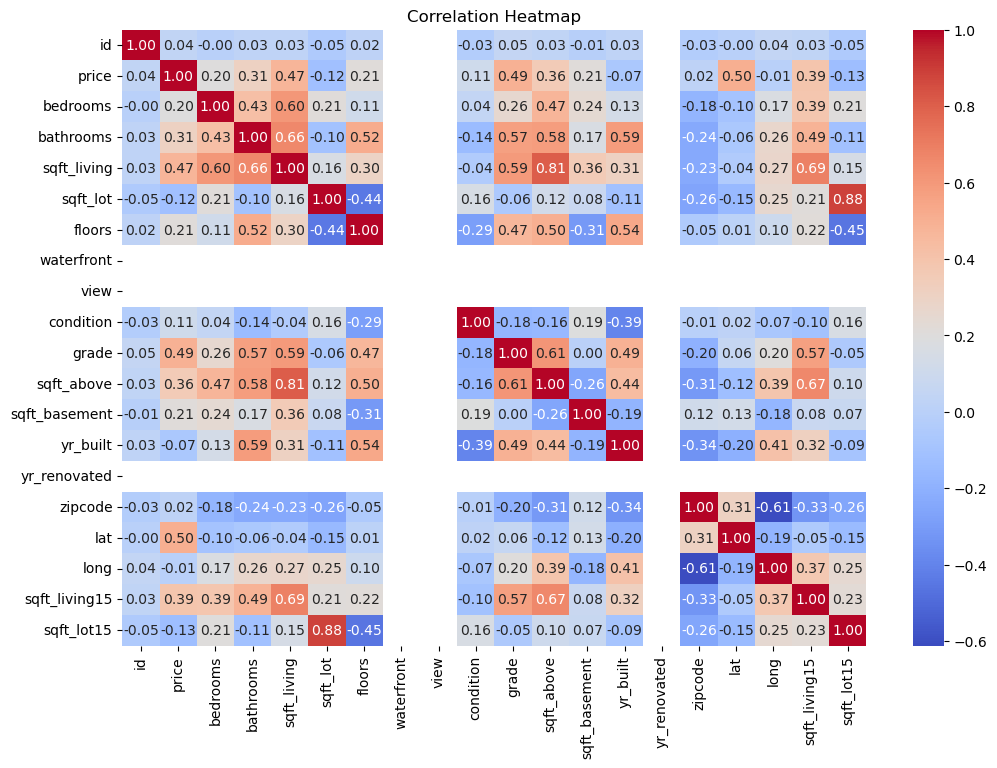

In [23]:
# Calculate the correlation between numerical features
correlation = df.select_dtypes(include=np.number).corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

# Add title
plt.title("Correlation Heatmap")

# Display the plot
plt.show()

# 25 Area vs House Price

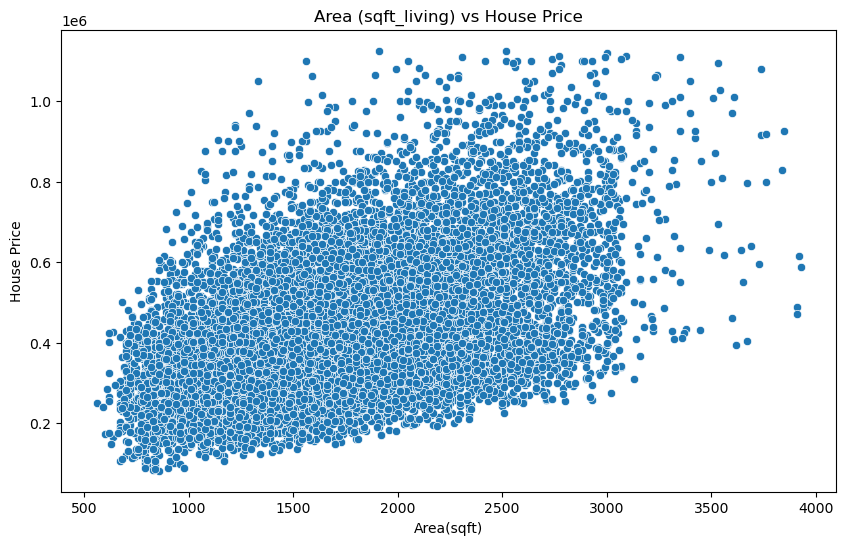

In [24]:
# Visualiza the relationship between house area and price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sqft_living', y="price")

# Add title and labels
plt.title("Area (sqft_living) vs House Price")
plt.xlabel("Area(sqft)")
plt.ylabel("House Price")

# Display the plot
plt.show()

# 26. Bedrooms vs House Price

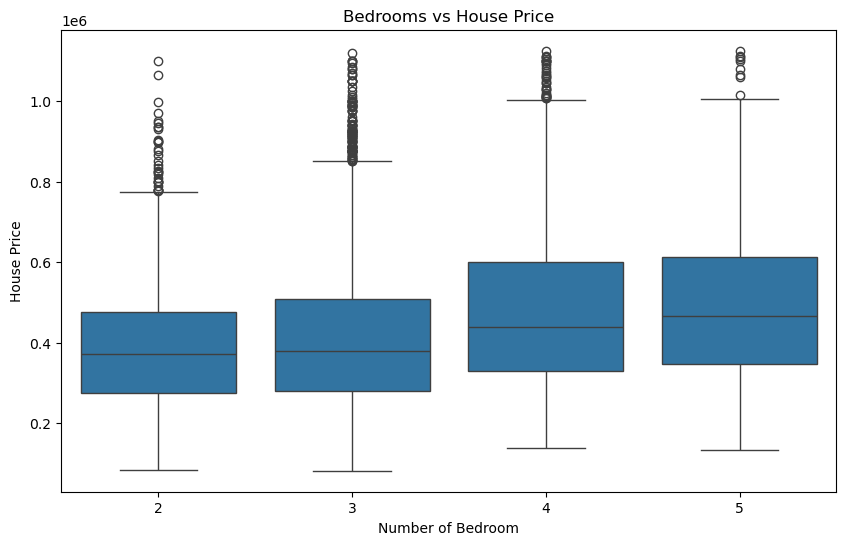

In [25]:
# Compare the number of bedrooms with house prices
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="bedrooms", y="price")

# Add title and labels
plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedroom")
plt.ylabel("House Price")

# Display the plot
plt.show()

# FEATURE ENGINEERING

# 27. Selecting Features and Target

In [26]:
# Separate the input features and target variable
x = df.drop("price", axis=1)
y = df["price"]

# Display the shapes of features and target
print("Features shape:", x.shape)
print("Target shape :", y.shape)

Features shape: (13868, 20)
Target shape : (13868,)


# 28. Encoding Categorical Features

In [27]:
# Ca\onvert categorical features into numerical dummy variables
x = pd.get_dummies(x, drop_first=True)

# Display the updated feature shape
print("Feature shape after encoding:", x.shape)

Feature shape after encoding: (13868, 385)


# 29. Handling Missing Values After Feature Engineering

In [28]:
# Fill any remaining missing values with median
x = x.fillna(x.median())

# Check for remaining missing vaalues
print("Total missing values:", x.isnull().sum().sum())

Total missing values: 0


# TRAIN-TEST SPLIT

# 30. Splitting the dataset

In [29]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Splitthe dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Display the shapesof training and testing data
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (11094, 385)
x_test shape: (2774, 385)
y_train shape: (11094,)
y_test shape: (2774,)


# MODEL BUILDING

# 31. Import Machine Learning Model

In [30]:
# Import the Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

# Create  the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 32. Train the Model

In [31]:
# Train the Random Forest model using the training data
model.fit(x_train, y_train)

# Display a confirmation message
print("Model trained Successfully!")

Model trained Successfully!


# 33. Make Predictions

In [32]:
# Predict house prices using the test data
y_pred = model.predict(x_test)

# Display the first 10 predicted prices
y_pred[:10]

array([236817.5 , 205530.84, 463745.63, 562159.5 , 441052.52, 479969.15,
       312411.5 , 267450.79, 570376.05, 235937.58])

# MODEL EVALUATION

# 34. Calculate MAE, MSE and RMSE

In [33]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Caculate R-squared score
r2 = r2_score(y_test, y_pred)

# Display evaluation results
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Rot Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Mean Absolute Error: 44532.368028118246
Mean Squared Error: 4068525344.415723
Rot Mean Squared Error: 63784.99309724602
R-squared Score: 0.8667905189072614


# 35. Actual vs Predicted Prices

In [34]:
# Calculate actual and predicted house prices
comparison = pd.DataFrame({"Actual Price": y_test.values, "Predicted Price": y_pred})

# Display the first 10 comparisons 
comparison.head(10)

,Actual Price,Predicted Price
0,223000.0,236817.50
1,165050.0,205530.84
2,518000.0,463745.63
3,533500.0,562159.50
4,400000.0,441052.52
5,435000.0,479969.15
6,390000.0,312411.50
7,259000.0,267450.79
8,542000.0,570376.05
9,252000.0,235937.58


# 36. Actual vs Predicted Visualization

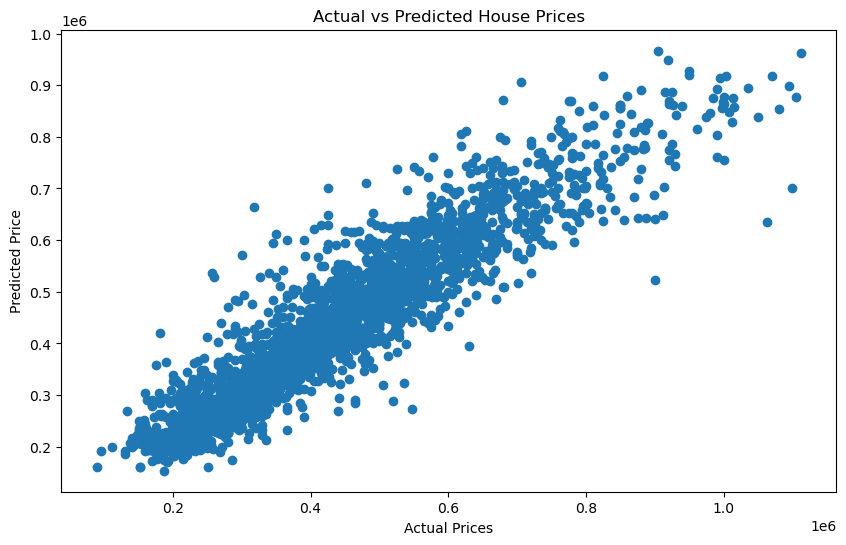

In [35]:
# Plot actual prices against predicted prices
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)

# Add title and labels
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Price")

# Display the plot
plt.show()

# FEATURE IMPORTANCE

#  37. Calculate Feature Importance

In [37]:
# Get the imp[ortance of each feature from the trained model
feature_importance = pd.DataFrame({"Feature": x.columns, "Importance": model.feature_importances_})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display the feature importance table
feature_importance

,Feature,Importance
15,lat,0.528696
3,sqft_living,0.232479
16,long,0.045909
17,sqft_living15,0.028834
10,sqft_above,0.021238
...,...,...
377,date_20150509T000000,0.000000
201,date_20141102T000000,0.000000
167,date_20140928T000000,0.000000
48,date_20140601T000000,0.000000


# 38. Visualize Feature Importance

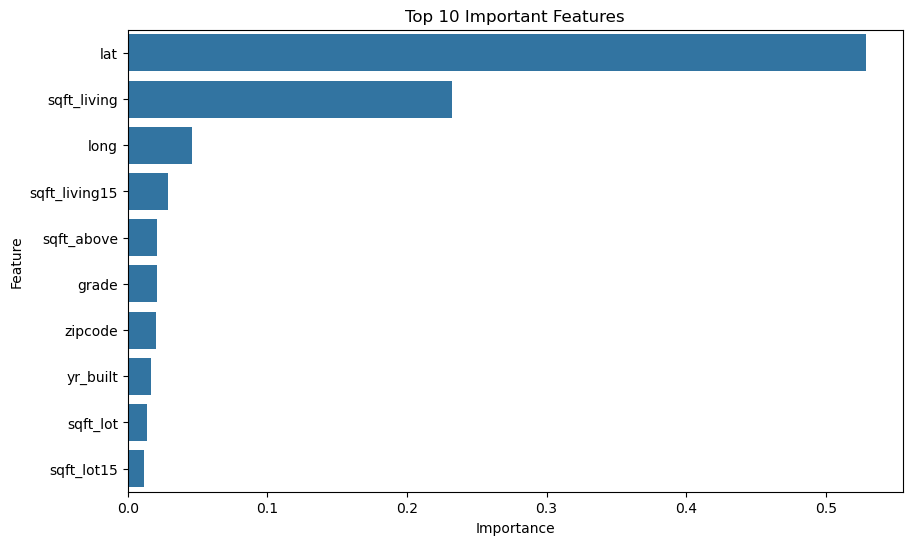

In [38]:
# Select the top 10 most important features
top_features = feature_importance.head(10)

# Create a bar chart of feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Importance", y="Feature")

# Add title and labels
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Display the plot
plt.show()

# 39. Final Conclusion

 In this project, we developed a Machine Learning model to predict house prices based on different property-related features. The dataset was cleaned and analyzes using exploratory data analysis and visualization techniques.

 After preprocessing and feature engineering, the dataset was divided into training and testing sets. A Random Forest Regression model was trained and evaluated using MAE, MSE, RMSE, and R^2 SCORE.

 Feature importance analysis helped us identify the features that contribute most to house price prediction. Overall, this project demonstrates how Machine Learning can be used to analyze housing data and predict property prices.